In [13]:
!unzip -o ./Data/cassava-disease.zip -d ./Data/
!unzip -o ./Data/train.zip -d ./Data/
!unzip -o ./Data/test.zip -d ./Data/

Archive:  ./Data/cassava-disease.zip
  inflating: ./Data/extraimages.zip  
  inflating: ./Data/random.txt       
  inflating: ./Data/sample_submission_file.csv  
  inflating: ./Data/test.zip         
  inflating: ./Data/train.zip        
Archive:  ./Data/train.zip
   creating: ./Data/train/
   creating: ./Data/train/cgm/
  inflating: ./Data/train/cgm/train-cgm-738.jpg  
  inflating: ./Data/train/cgm/train-cgm-704.jpg  
  inflating: ./Data/train/cgm/train-cgm-710.jpg  
  inflating: ./Data/train/cgm/train-cgm-248.jpg  
  inflating: ./Data/train/cgm/train-cgm-260.jpg  
  inflating: ./Data/train/cgm/train-cgm-506.jpg  
  inflating: ./Data/train/cgm/train-cgm-512.jpg  
  inflating: ./Data/train/cgm/train-cgm-274.jpg  
  inflating: ./Data/train/cgm/train-cgm-328.jpg  
  inflating: ./Data/train/cgm/train-cgm-314.jpg  
  inflating: ./Data/train/cgm/train-cgm-472.jpg  
  inflating: ./Data/train/cgm/train-cgm-466.jpg  
  inflating: ./Data/train/cgm/train-cgm-300.jpg  
  inflating: ./Data/train/c

In [25]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.cli import tqdm
from tqdm import trange

from PIL import Image
import os
from pathlib import Path

## Data Preparing

In [53]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(360),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [54]:
train_dataset = datasets.ImageFolder(root="./Data/train", transform=transform_train)
test_dataset = datasets.ImageFolder(root="./Data/test", transform=transform_test)

train_dataset.class_to_idx

{'cbb': 0, 'cbsd': 1, 'cgm': 2, 'cmd': 3, 'healthy': 4}

In [55]:
len(train_dataset)

5656

In [56]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

In [57]:
# в тренировочную выборку отнесем 80% всех картинок
train_size = int(len(train_dataset) * 0.8)
# в валидационную — остальные 20%
val_size = len(train_dataset) - train_size

train_data, val_data = torch.utils.data.random_split(train_dataset, [train_size, val_size])

In [58]:
train_loader = torch.utils.data.DataLoader(train_data, batch_size=256, shuffle=True, num_workers=8, persistent_workers=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=256, shuffle=False, num_workers=8, persistent_workers=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=8, persistent_workers=True)

In [59]:
def show_images(images, labels):
    f, axes= plt.subplots(1, 10, figsize=(30,5))

    for i, axis in enumerate(axes):
        # переводим картинку из тензора в numpy
        img = images[i].numpy()
        # переводим картинку в размерность (длина, ширина, цветовые каналы)
        img = np.transpose(img, (1, 2, 0))

        axes[i].imshow(img)
        axes[i].set_title(labels[i].numpy())

    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.1461596].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0776608].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.0784314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.3935575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5179958].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.428

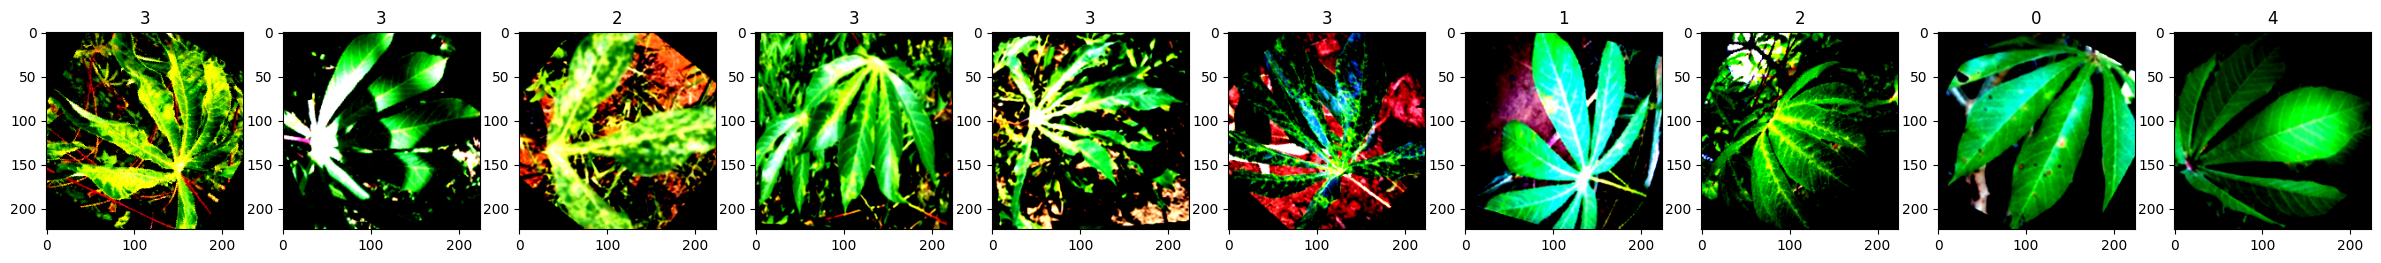

In [60]:
for batch in train_loader:
    # батч картинок и батч ответов к картинкам
    images, labels = batch
    break

show_images(images, labels)

## Model

In [61]:
class CassavaClassifier(nn.Module):
    def __init__(
            self,
            img_shape: tuple[int, int, int],
            in_ch: int,
            hidden_ch: list[int],
            hidden_fc: list[int],
            output_dim: int,
            conv_dropout = 0.2,
            fc_dropout = 0.3
        ):
        super(CassavaClassifier, self).__init__()

        conv_layers = [
            nn.Conv2d(in_channels=in_ch, out_channels=hidden_ch[0], kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden_ch[0]),
            nn.ReLU()
            # nn.Dropout2d(conv_dropout)
        ]

        last_dim = hidden_ch[0]

        for i in range(2, len(hidden_ch)):
            conv_layers.extend([
                nn.Conv2d(in_channels=last_dim, out_channels=hidden_ch[i], kernel_size=3, padding=1),
                nn.BatchNorm2d(hidden_ch[i]),
                nn.ReLU(),
                nn.Dropout2d(conv_dropout),
                nn.MaxPool2d(kernel_size=2, stride=2)
            ])
            last_dim = hidden_ch[i]
        
        self.conv_part = nn.Sequential(*conv_layers)

        fc_layers = []

        last_dim = self._after_conv_shape(img_shape, self.conv_part)
        
        for dim in hidden_fc:
            fc_layers.extend([
                nn.Linear(last_dim, dim),
                nn.BatchNorm1d(dim),
                nn.ReLU(),
                nn.Dropout(fc_dropout)
            ])
            last_dim = dim

        fc_layers.extend([
            nn.Linear(last_dim, output_dim)
        ])
        
        self.fc_part = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.conv_part(x)
        flaten = nn.Flatten()
        x = flaten(x)
        x = self.fc_part(x)
        return x

    def _after_conv_shape(self, img_shape, conv_part) -> np.array:
        X = torch.Tensor(size=[1, *img_shape])
        flat = nn.Flatten()
        X_out = flat(conv_part(X))
        return X_out[0].shape[0]



## Train

In [62]:
def train(
        train_loader: DataLoader,
        val_loader: DataLoader,
        model: nn.Module,
        optimizer: torch.optim.AdamW,
        criterion = nn.CrossEntropyLoss(),
        num_epoches = 100
    ):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses = []
    val_losses = []
    val_metric = []

    for epoch in trange(num_epoches):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()



    return model

In [64]:
model = CassavaClassifier(
    img_shape=(3, 224, 224),
    in_ch=3,
    hidden_ch=[64, 128, 128, 64],
    hidden_fc=[512, 256],
    output_dim=5    
)

model

CassavaClassifier(
  (conv_part): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): Dropout2d(p=0.2, inplace=False)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout2d(p=0.2, inplace=False)
    (12): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_part): Sequential(
    (0): Linear(in_features=200704, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, t